In [62]:
import matplotlib.pyplot as plt
import numpy as np

## Soluzione del problema dei minimi quadrati nel caso polinomiale.

I dati del problema sono le coppie di punti in ${\mathbb R}^2$
$$(x_i,y_i), i= 1,...,m $$
e assumiamo per essi un modello polinomiale
$$f(x;a_0,a_1,...,a_{n-1}) = a_0+a_1x+...+a_{n-1}x^{n-1} $$
Applicare il criterio dei minimi quadrati significa calcolare i parametri $a_0,a_1,...,a_{n-1}$ tali che la quantità che esprime la distanza verticale quadratica cumulativa

$$ Q(a_0,a_1,...,a_{n-1}) = \sum_{i=1}^m(f(x_i;a_0,a_1,...,a_{n-1})-y_i)^2$$
sia minima rispetto a tutte le possibili scelte di $a_i\in{\mathbb R}$, $i=0,...,n-1$.

Introducendo la notazione
$$\alpha = \begin{pmatrix}a_0\\a_1\\\vdots\\a_{n-1} \end{pmatrix}\in{\mathbb R}^n, \ \ y = \begin{pmatrix}y_1\\y_2\\\vdots\\y_m \end{pmatrix}\in{\mathbb R}^m $$

nel caso del modello polinomiale, la funzione di distanza $Q$ si scrive anche come
$$Q(\alpha) = \|A\alpha-y\|^2$$
dove
$$A = \begin{pmatrix} 1 &x_1&x_1^2& ... & x_1^{n-1}\\ 1 & x_2&x_2^2&...&x_2^{n-1} \\ \vdots&\vdots&\vdots&&\vdots \\ 1 & x_m&x_m^2&...&x_m^{n-1} \end{pmatrix}\in {\mathbb R}^{m\times n}$$

Si può dimostrare che, se $n\leq m$, le colonne di $A$ sono linearmente indipendenti. In conseguenza di ciò si può applicare la fattorizzazione QR di $A$ e trovare una matrice $Q\in{\mathbb R^{m\times m}}$ ortogonale e una matrice $R\in{\mathbb R}^{n\times n}$ triangolare superiore non singolare tali che
$$A = Q\begin{pmatrix} Q\\0\end{pmatrix} $$
dove '$0$' rappresenta la matrice di dimensione $(m-n)\times n$ con tutti gli elementi nulli.

L'algoritmo per il calcolo della soluzione del problema dei minimi quadrati
$$\min_{\alpha\in{\mathbb R}^n}\|A\alpha-y\|^2 $$
consiste nei seguenti passi
1. Calcolare la fattorizzazione
$$A = Q\begin{pmatrix} R \\0 \end{pmatrix} $$
mediante trasformazioni di Householder
2. Calcolare $\tilde y=Q^T y$.
3. Estrarre le prime $n$ componenti di $\tilde y$ e memorizzarle nel vettore $\tilde y_1$
4. Risolvere il sistema triangolare superiore $R\alpha = \tilde y_1$.




In [63]:
from scipy.linalg import qr, solve_triangular

def vandermonde_n(x,n):
  #Matrice di Vandermonde rettangolare
  #n = numero di colonne della matrice
  A = np.ones((x.size,n))
  for i in range(1,n):
    A[:,i] = A[:,i-1]*x
  return A

def pol_minquad(x,y,n):
  #n = grado del polinomio
  n += 1 # Numero di colonne della matrice di regressione
  #x.size = Numero di righe della matrice di regressione
  A = vandermonde_n(x,n)
  Q,r = qr(A)            # 1. Fattorizzazione QR
  R = r[:n,:n]           #    r contiene anche gli zeri sotto, che togliamo
  y_tilde  = Q.T@y       # 2. prodotto matriciale
  y_tilde1 = y_tilde[:n] # 3. Otteniamo le prime n componenti da y_tilde
  return solve_triangular(R,y_tilde1) # 4. Risoluzione del sistema lineare (Triangolare superiore)

In [64]:
x = np.array([0,2,5,8,10,11.])
y = np.array([-1,3,2,9,10,12.])

# Terzo parametro fissato ad 1: Vogliamo calcolare la retta 
# di regressione che approssimi meglio i punti dati.
a = pol_minquad(x,y,2) # <---
print(a)
p = np.polyfit(x,y,2) # <---
print(p)

# (Polifit è il metodo dei minimi quadrati implementata in np).

# E' possibile incrementare il numero di parametri
# e notare otteremo non più una retta ma una curva
# che approssima la funzione in modo migliore.

# Più aumentiamo il grado. più ci avviciniamo al caso dell'interpolazione
# Con 1 parametro --> Una retta che cerca di assumere la funzione originale
# Con 2 parametri --> Una curva che segue meglio i punti
# Con 5 Parametri --> Otteniamo praticamente un'interpolazione

# Stiamo approssimando, ma stiamo in realtà interpolando

# Overfitting. In realtà noi vogliamo stare lontani dai punti.
# Se usiamo un numero di parametri troppo alto rischiamo di seguire troppo bene i punti
# e attuare una sorta di interpolazione, anche se non vogliamo.

[-0.29190149  0.654864    0.04196275]
[ 0.04196275  0.654864   -0.29190149]


Residuo Q(a_1,...,a_n+1) = 9.99516049987748


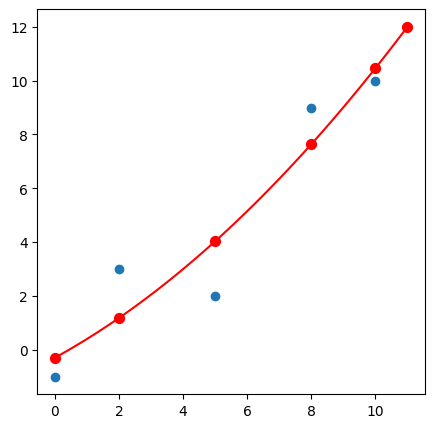

In [65]:
#plot dei dati
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1)
ax.scatter(x,y)

# Valuta il polinomio di approssimazione calcolato in precedenza
f = lambda a,x : np.polyval(a[-1::-1],x)

fi = f(a,x)

# Creiamo un vettore di ascisse per mostrare la retta
xx = np.linspace(x.min(),x.max(),100)
ax.plot(xx,f(a,xx),color='red')
ax.scatter(x,fi,color='red',s=50)
print("Residuo Q(a_1,...,a_n+1) =", np.linalg.norm(y-fi)**2) # stampa dei residui

## Applicazione della regressione polinomiale su dati reali

I polinomi di grado 3 sono molto utilizzati in ambito finanziario per costruire dei modelli quantitativi a breve termine dell'andamento dei titoli azionari.

E' infatti noto che durante la giornata di contrattazione il valore di un titolo segue una tipica curva ad "S": un rialzo iniziale, seguito da una discesa e da una risalita finale prima della chiusura.

Si tratta di curve che hanno quindi due punti di estremo relativo (un massimo e un minimo relativo) e i polinomi di grado 3 hanno questa stessa caratteristica (la loro derivata è un polinomio di grado 2 che si annulla in al massimo 2 punti).

Nel seguito descriviamo un esempio semplificato di applicazione del polinomio di regressione di grado 3 per un'analisi a posteriori dell'andamento di un titolo finanziario.

I dati del problema sono
$$ (x_i,y_i), i = 1,...,m$$
dove $x_i$ sono gli istanti temporali di rilevazione del dato e $y_i$ è il valore del titolo azionario in quell'istante.

Indichiamo con $p(x)$ il polinomio di grado 3 costruito con il criterio dei minimi quadrati su questi dati e calcoliamo
$$\tilde y_i = p(x_i)$$

Gli operatori finanziari traggono alcune informazioni di massima dal confronto tra i dati reali $y_i$ e il dato che il modello produce $\tilde y_i$.

In particolare vengono create delle bande (o canali) di regressione nel seguente modo.
1. Si calcola la deviazione standard nel modo seguente
$$\begin{array}{lcl}
e_i &=& y_i - \tilde y_i\\
\bar e &=& \frac 1 m \sum_{i=1}^m e_i\\
\text{dev}&=&   \frac 1 m \sqrt{\sum_{i=1}^m(e_i-\bar e)^2}
\end{array} $$
2. Si sceglie un fattore positivo $n_b$ (tipicamente 2,3) e si definiscono due curve
$$ \begin{array}{lcl}
p(x) + n_b\cdot\text{dev}\\
p(x) - n_b\cdot\text{dev}
\end{array}$$
all'interno delle quali si trova il modello polinomiale calcolato e i dati che hanno una certa coerenza statistica con esso.

Il grafico ottenuto serve per
1. tracciare l'andamento complessivo della giornata di contrattazione
2. individuare i momenti della giornata in cui si è verificato il cambiamento crescita/diminuzione
3. individuare le "anomalie"

Scaricamento dati per AAPL...


[*********************100%***********************]  1 of 1 completed


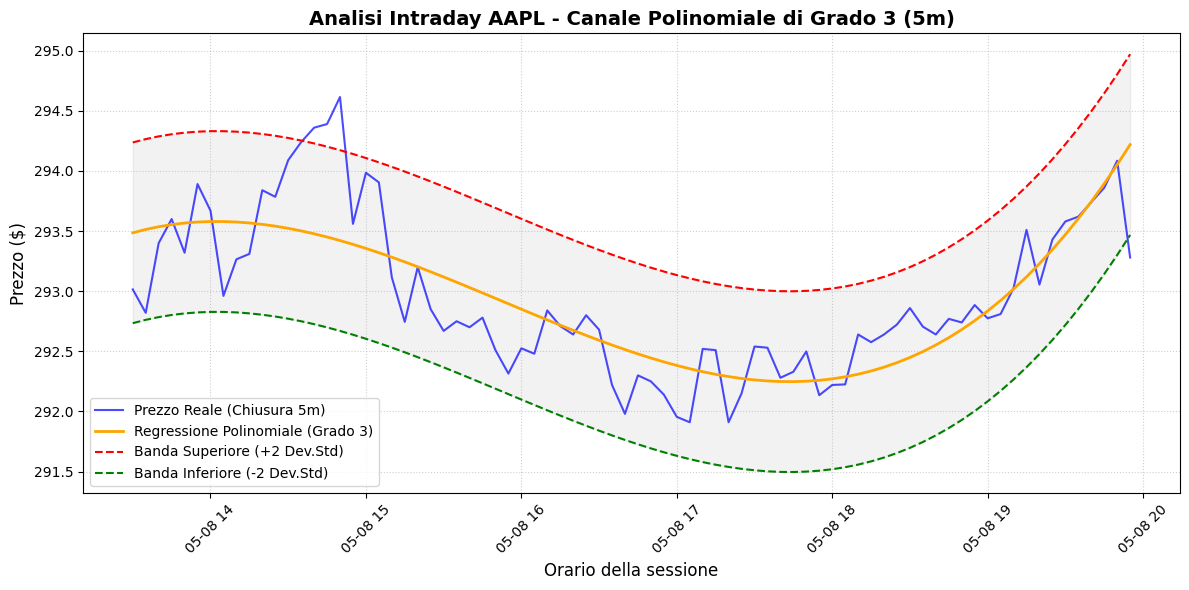

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# 1. Configurazione dei parametri per yfinance
TICKER = "AAPL"       # Titolo azionario reale (borsa USA)
PERIODO = "1d"        # Ultimo giorno di borsa aperto
INTERVAL = "5m"       # Dati a 5 minuti

print(f"Scaricamento dati per {TICKER}...")
# Scarica i dati in un DataFrame Pandas
df = yf.download(tickers=TICKER, period=PERIODO, interval=INTERVAL)


# 2. Estrazione dei prezzi di chiusura dell'intervallo a 5 minuti che corrispondono all'etichetta 'Close'.
# Con "squeeze" togliamo, se esiste, la seconda dimensione dei dati (il codice presuppone la scelta di un'unico tipo di azione)
y = np.squeeze(df['Close'].dropna().values)
m = y.size

# Creiamo le ascisse dei dati come interi 0 a N-1, perché la spaziatura dei dati è uniforme
# L'unità di misura sull'asse delle ascisse sarà quindi "5m"
x = np.arange(m)

# 3. Calcolo dell'approssimazione polinomiale di grado 3 con il criterio dei minimi quadrati
p = np.polyfit(x, y, deg=3)

# Calcola i valori del modello polinomiale in corrispondenza delle ascisse dei dati
y_pol = np.polyval(p, x)

# 4. Creazione delle Bande di Oscillazione (Canale di regressione/deviazione standard)
# Calcola la differenza (residui) tra i prezzi reali e la curva cubica
residui = y - y_pol
media_residui = np.mean(residui)
deviazione_standard   = np.sqrt(((residui-media_residui)**2).sum()/len(residui))
#deviazione_standard = np.std(residui)

# Imposta la larghezza del canale (es. 2 deviazioni standard)
n_b = 2
banda_superiore = y_pol + (n_b * deviazione_standard)
banda_inferiore = y_pol - (n_b * deviazione_standard)

# 5. Visualizzazione Grafica
plt.figure(figsize=(12, 6))

# Traccia i prezzi reali
plt.plot(df.index, y, label="Prezzo Reale (Chiusura 5m)", color="blue", alpha=0.7, linewidth=1.5)

# Traccia il grafico del polinomio di regressione di grado 3
plt.plot(df.index, y_pol, label="Regressione Polinomiale (Grado 3)", color="orange", linewidth=2)

# Traccia le bande di oscillazione
plt.plot(df.index, banda_superiore, label="Banda Superiore (+2 Dev.Std)", color="red", linestyle="--")
plt.plot(df.index, banda_inferiore, label="Banda Inferiore (-2 Dev.Std)", color="green", linestyle="--")

# Riempie lo spazio interno alle bande per evidenziare il canale statistico
plt.fill_between(df.index, banda_inferiore, banda_superiore, color='gray', alpha=0.1)

# Formattazione del grafico
plt.title(f"Analisi Intraday {TICKER} - Canale Polinomiale di Grado 3 ({INTERVAL})", fontsize=14, fontweight='bold')
plt.xlabel("Orario della sessione", fontsize=12)
plt.ylabel("Prezzo ($)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="lower left")
plt.xticks(rotation=45)
plt.tight_layout()


plt.show()